In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface
import spikeinterface.exporters as sexp
from spikeinterface.core import write_binary_recording
from pathlib import Path
import pickle
from utils_clique import (
    CliqueInfo,
    build_shank_cliques,
    neuron_inf_dict_to_dataframe,
    get_recording_clique,
    filter_neuron_inf_by_clique,
    filter_gt_detect_array_by_clique,
    prepare_training_data,
    train_autosort_model,
    calibration_model,
    SimpleAutoSort,
    real_time_processing
)


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 定义第2-12个月的session列表（不含第1个月）
session_names = [
    'mouse6_022522_natural_image_001',
    'mouse6_031722_natural_image_001',
    'mouse6_042422_natural_image_001',
    'mouse6_052422_natural_image_001',
    'mouse6_062422_natural_image_001',
    'mouse6_072322_natural_image_001',
    'mouse6_082322_natural_image_001',
    'mouse6_092422_natural_image_001',
    'mouse6_102122_natural_image_001',
    'mouse6_112022_natural_image_001',
    'mouse6_122022_natural_image_001',
]

output_folder = '/media/ubuntu/sda/mouse_test/script/end2end/spike_sorting_model'
combined_output_base = output_folder

probe_30channel = read_probeinterface('/media/ubuntu/sda/data/probe.json')

print(f"共 {len(session_names)} 个sessions，将在后续cell中逐个单独处理")

共 11 个sessions，将在后续cell中逐个单独处理


In [3]:
import torch

# 指定训练session和测试sessions
train_session_name = 'mouse6_021322_natural_image_001'
clique_id = 0

# 创建单个包含所有30个通道的clique（与训练时一致）
probe_df = probe_30channel.to_dataframe()
all_channel_ids = probe_df['contact_ids'].astype(str).tolist()
cliques = [
    CliqueInfo(
        clique_id=0,
        device_channel_indices=list(range(len(all_channel_ids))),
        contact_ids=all_channel_ids,
        center=(probe_df['x'].mean(), probe_df['y'].mean())
    )
]

# 加载训练session的neuron_inf
train_data_folder = f'{combined_output_base}/clique_{clique_id}/{train_session_name}'
train_neuron_inf_path = f'{train_data_folder}/neuron_inf.pickle'

if not os.path.exists(train_neuron_inf_path):
    raise FileNotFoundError(f'训练session的neuron_inf文件不存在: {train_neuron_inf_path}')

with open(train_neuron_inf_path, 'rb') as f:
    train_neuron_inf_dict = pickle.load(f)

train_neuron_inf = neuron_inf_dict_to_dataframe(train_neuron_inf_dict)
print(f"训练session {train_session_name}: {len(train_neuron_inf)} 个神经元")

# 读取trigger数据
trigger_time_path = '/media/ubuntu/sda/data/mouse6/output/01_get_trigger/trigger_time.tsv'
trigger_df = pd.read_csv(trigger_time_path, sep='\t')
trigger_df['date'] = trigger_df['date'].astype(str).str.zfill(6)

print(f"\n读取到 {len(trigger_df)} 个trials")
print(f"列名: {trigger_df.columns.tolist()}")

clique = cliques[0]
samplepoints = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\n准备逐个session处理，共 {len(session_names)} 个sessions")
print(f"训练session: {train_session_name}")
print(f"测试sessions: {session_names}")

训练session mouse6_021322_natural_image_001: 31 个神经元

读取到 19773 个trials
列名: ['Unnamed: 0', 'start', 'end', 'date', 'image', 'order']

准备逐个session处理，共 11 个sessions
训练session: mouse6_021322_natural_image_001
测试sessions: ['mouse6_022522_natural_image_001', 'mouse6_031722_natural_image_001', 'mouse6_042422_natural_image_001', 'mouse6_052422_natural_image_001', 'mouse6_062422_natural_image_001', 'mouse6_072322_natural_image_001', 'mouse6_082322_natural_image_001', 'mouse6_092422_natural_image_001', 'mouse6_102122_natural_image_001', 'mouse6_112022_natural_image_001', 'mouse6_122022_natural_image_001']


In [ ]:
import os
import pickle
import numpy as np
import torch

import neo
from elephant.kernels import GaussianKernel
from elephant.statistics import instantaneous_rate
from quantities import ms, s

model_save_dir = f'/media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim_full/clique_0/mouse6_021322_natural_image_001/model_1'
noise_model_path = f'{model_save_dir}/multitask_single_wave_clsfier_noise_clsfier.pth'
label_model_path = f'{model_save_dir}/multitask_single_wave_clsfier_label_clsfier.pth'
classification_mapping_path = f'{model_save_dir}/classification_mapping.pkl'

OUTPUT_DIR = '/media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim_full/psth'
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXTEND_TIME = 0.25
STIMULUS_DURATION = 1.0
bin_size_ms = 50
bin_size_s = bin_size_ms / 1000.0
gk = GaussianKernel(150 * ms)

total_time_extended = EXTEND_TIME + STIMULUS_DURATION + EXTEND_TIME
n_time_bins = int(np.ceil(total_time_extended / bin_size_s))
extend_bins = int(EXTEND_TIME / bin_size_s)
stimulus_bins = int(STIMULUS_DURATION / bin_size_s)
stimulus_start_bin = extend_bins
stimulus_end_bin = extend_bins + stimulus_bins


with open(classification_mapping_path, 'rb') as f:
    classification_mapping = pickle.load(f)
keep_id_list = classification_mapping['label_list']


for sess_idx, sess_name in enumerate(session_names):
    date_str = sess_name.split('_')[1]
    print(f"\n{'='*60}")
    print(f"处理session {sess_idx+1}/{len(session_names)}: {sess_name} (date={date_str})")
    print(f"{'='*60}")
    
    file_path = f'/media/ubuntu/sda/data/mouse6/ns4/natural_image/{sess_name}.ns4'
    recording_raw = se.read_blackrock(file_path=file_path)
    recording_recorded = recording_raw.remove_channels(["98", '31', '32'])
    recording_recorded = recording_recorded.set_probegroup(probe_30channel)
    
    recording_f = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
    recording_notch = spre.notch_filter(recording_f, freq=60)
    recording_cmr_session = spre.common_reference(recording_f, reference="global", operator="median")
    recording_cmr_session = recording_cmr_session.rename_channels(['A-000', 'A-001', 'A-002', 'A-003', 'A-004',
                                   'A-005', 'A-006', 'A-007', 'A-008', 'A-009',
                                   'A-0010', 'A-011', 'A-012', 'A-013', 'A-014',
                                   'A-015', 'A-016', 'A-017', 'A-018', 'A-019',
                                   'A-020', 'A-021', 'A-022', 'A-023', 'A-024',
                                   'A-025', 'A-026', 'A-027', 'A-028', 'A-029'])
    
    SAMPLING_RATE = int(recording_cmr_session.get_sampling_frequency())
    session_recording_clique = get_recording_clique(recording_cmr_session, clique)
    n_channels = session_recording_clique.get_num_channels()
    
    print(f"Session recording: {n_channels} channels, {recording_cmr_session.get_num_samples()} samples")
    
    autosort_model = SimpleAutoSort(
        ch_num=n_channels,
        samplepoints=samplepoints,
        device=device,
        set_shank_id=keep_id_list,
        save_dir=model_save_dir,
        pos_weight_noise=None,
        pos_weight_label=None
    )
    autosort_model.clsfier_noise.load_state_dict(torch.load(noise_model_path, map_location=device))
    autosort_model.clsfier_label.load_state_dict(torch.load(label_model_path, map_location=device))
    autosort_model.eval()
    
    test_data_folder = f'{combined_output_base}/clique_{clique_id}/{sess_name}'
    test_neuron_inf_path = f'{test_data_folder}/neuron_inf.pickle'
    
    eval_neuron_inf = None
    if os.path.exists(test_neuron_inf_path):
        with open(test_neuron_inf_path, 'rb') as f:
            test_neuron_inf_dict = pickle.load(f)
        
        test_neuron_inf = neuron_inf_dict_to_dataframe(test_neuron_inf_dict)
        print(f"测试session {sess_name}: {len(test_neuron_inf)} 个神经元")
        
        print(f"\n{'='*60}")
        print("比较神经元（直接比较neuron ID）")
        print(f"{'='*60}")
        
        train_neuron_ids = set(train_neuron_inf['Neuron'].unique())
        test_neuron_ids = set(test_neuron_inf['Neuron'].unique())
        
        # 统计结果
        matched_neuron_ids = train_neuron_ids & test_neuron_ids  # 重合的神经元
        disappeared_neuron_ids = train_neuron_ids - test_neuron_ids  # 消失的神经元
        new_neuron_ids = test_neuron_ids - train_neuron_ids  # 新出现的神经元
        
        print(f"\n统计结果:")
        print(f"  重合的神经元: {len(matched_neuron_ids)} (在{train_session_name}和{sess_name}中都存在)")
        if len(matched_neuron_ids) > 0:
            print(f"    重合的神经元列表: {sorted(matched_neuron_ids)}")
        print(f"  消失的神经元: {len(disappeared_neuron_ids)} (在{train_session_name}中存在但在{sess_name}中不存在)")
        if len(disappeared_neuron_ids) > 0:
            print(f"    消失的神经元列表: {sorted(disappeared_neuron_ids)}")
        print(f"  新出现的神经元: {len(new_neuron_ids)} (在{sess_name}中存在但在{train_session_name}中不存在)")
        if len(new_neuron_ids) > 0:
            print(f"    新出现的神经元列表: {sorted(new_neuron_ids)}")
        
        test_neuron_inf_matched = test_neuron_inf.copy()
        test_neuron_inf_matched['neuron_match'] = test_neuron_inf_matched['Neuron'].apply(
            lambda x: x if x in matched_neuron_ids else 'unmatch'
        )
        eval_neuron_inf = test_neuron_inf_matched
    else:
        print(f"警告: 测试session的neuron_inf文件不存在: {test_neuron_inf_path}，将跳过神经元匹配评估")
    
    gt_detect_array_path = f'{combined_output_base}/clique_{clique_id}/{sess_name}/gt_detect_array.csv'
    gt_detect_array = None
    if os.path.exists(gt_detect_array_path):
        gt_detect_array = pd.read_csv(gt_detect_array_path)
        print(f'已加载gt_detect_array: {len(gt_detect_array)} 条记录')
    else:
        print(f'警告: gt_detect_array文件不存在: {gt_detect_array_path}')
    
    session_out_dir = os.path.join(OUTPUT_DIR, sess_name)
    os.makedirs(session_out_dir, exist_ok=True)    
    
    session_trig = trigger_df[trigger_df['date'] == date_str].copy().reset_index(drop=False)
    print(f'本月trials数: {len(session_trig)}')
    
    trigger_starts = session_trig['start'].values.astype(int)
    min_trigger = int(trigger_starts.min())
    max_trigger = int(trigger_starts.max())
    
    extend_seconds = 10.0
    extend_samples_total = int(extend_seconds * SAMPLING_RATE)
    process_start_global = max(0, min_trigger - extend_samples_total)
    process_end_global = min(recording_cmr_session.get_num_samples(), max_trigger + extend_samples_total)
    
    print(f'  处理区域: {process_start_global} 到 {process_end_global} (sample points)')
    print(f'  对应时间: {process_start_global/SAMPLING_RATE:.2f}s 到 {process_end_global/SAMPLING_RATE:.2f}s')
    print(f'  Trigger范围: {min_trigger} 到 {max_trigger} (sample points)')
    
    segment_duration_seconds = 1000.0
    segment_length_samples = int(segment_duration_seconds * SAMPLING_RATE)
    total_length = process_end_global - process_start_global
    n_segments = int(np.ceil(total_length / segment_length_samples))
    print(f'  划分为{n_segments}段，每段长度: {segment_length_samples} samples ({segment_duration_seconds}s)')
    
    all_spike_times_absolute = []
    all_spike_predictions = []
    
    for seg_idx in range(n_segments):
        seg_start = process_start_global + seg_idx * segment_length_samples
        seg_end = min(process_start_global + (seg_idx + 1) * segment_length_samples, process_end_global)
        
        # 提取这段数据
        segment_recording = recording_cmr_session.frame_slice(start_frame=seg_start, end_frame=seg_end)
        segment_recording_clique = get_recording_clique(segment_recording, clique)
        
        # 计算这段的实际时长（秒）
        segment_duration_seconds_actual = (seg_end - seg_start) / SAMPLING_RATE
        
        print(f'\n  处理段 {seg_idx+1}/{n_segments}: {seg_start} 到 {seg_end} (sample points, {seg_start/SAMPLING_RATE:.2f}s - {seg_end/SAMPLING_RATE:.2f}s, 总时长 {segment_duration_seconds_actual:.2f}s)')
        gt_detect_array_seg = gt_detect_array[(gt_detect_array['time'] > seg_start) & (gt_detect_array['time'] <= seg_end)]
        gt_detect_array_seg['time'] = gt_detect_array_seg['time'] - seg_start
        print(f'    用整段数据 ({segment_duration_seconds_actual:.2f}s) 做calibration...')
        segment_calibration_results = calibration_model(
            recording_f=segment_recording_clique,
            autosort_model=autosort_model,
            train_neuron_inf=train_neuron_inf,
            calibration_duration_seconds=segment_duration_seconds_actual,
            n_additional_clusters=5,
            detection_params={
                'thr_min': 5,
                'thr_max': 35,
                'distance': 3,
                'wlen': 5,
                'prominence': 20,
                'max_firing_channel': 10,
            },
            window_params={
                'left_sample': 10,
                'right_sample': 20,
            },
            position_threshold=15.0,
            waveform_similarity_threshold=0.9,
            eval_neuron_inf=eval_neuron_inf,
            gt_detect_array=gt_detect_array_seg,
            match_mode='per_channel_match',
            device=device
        )
        print(f'Calibration完成')
        
        results_df = segment_calibration_results['results_df']
        
        valid_mask = results_df['predicted_label'] != 'noise'
        valid_results = results_df[valid_mask].copy()
        
        spike_times_segment = valid_results['spike_time'].values.astype(int)
        spike_times_absolute = spike_times_segment + seg_start  # 转换为绝对值
        
        spike_predictions = valid_results['predicted_label'].values.tolist()
        
        all_spike_times_absolute.extend(spike_times_absolute.tolist())
        all_spike_predictions.extend(spike_predictions)
        
        print(f'    检测到 {len(spike_times_absolute)} 个spikes (过滤noise后)')
    
    all_spike_times_absolute = np.array(all_spike_times_absolute)
    print(f'\n  总共检测到 {len(all_spike_times_absolute)} 个spikes')
    print(f'  Spike times范围: {all_spike_times_absolute.min()} 到 {all_spike_times_absolute.max()} (相对于整个recording的绝对值)')
    
    extend_samples = int(EXTEND_TIME * SAMPLING_RATE)
    stimulus_samples = int(STIMULUS_DURATION * SAMPLING_RATE)
    total_extended_samples = extend_samples + stimulus_samples + extend_samples
    
    spikes_by_trial = {}
    for trial_i, row in session_trig.iterrows():
        trial_id = int(row['index']) if 'index' in row else int(trial_i)
        trial_start = int(row['start'])
        
        trial_window_start = trial_start - extend_samples
        trial_window_end = trial_start + stimulus_samples + extend_samples
        
        mask = (all_spike_times_absolute >= trial_window_start) & (all_spike_times_absolute <= trial_window_end)
        trial_spike_times = all_spike_times_absolute[mask]
        trial_spike_preds = [all_spike_predictions[i] for i in np.where(mask)[0]]
        
        spike_times_relative_to_trial_start = trial_spike_times - trial_start
        
        trial_key = f'trial_{trial_id}'
        spikes_by_trial[trial_key] = {}
        for st, neu in zip(spike_times_relative_to_trial_start, trial_spike_preds):
            if neu == 'unmatch':
                continue
            spikes_by_trial[trial_key].setdefault(neu, []).append(int(st))
    
    print(f'有效trials: {len(spikes_by_trial)}')
    
    train_neuron_ids_standard = sorted(train_neuron_inf['Neuron'].unique().tolist())
    n_trials = len(session_trig)
    n_neurons = len(train_neuron_ids_standard)
    
    print(f'\n使用训练session的neuron ID作为标准: {train_neuron_ids_standard}')
    print(f'共 {n_neurons} 个neuron（所有月份PSTH矩阵将按此顺序对齐）')
    
    psth_full = np.zeros((n_trials, n_time_bins, n_neurons), dtype=np.float32)
    trial_image_ids = []
    

    for trial_i, row in session_trig.iterrows():
        trial_id = int(row['index']) if 'index' in row else int(trial_i)
        trial_key = f'trial_{trial_id}'
        trial_image_ids.append(int(row['image']))
        
        for nj, neu_id in enumerate(train_neuron_ids_standard):
            spk = []
            # 检查该neuron在当前trial是否有spike
            if trial_key in spikes_by_trial and neu_id in spikes_by_trial[trial_key]:
                spk = spikes_by_trial[trial_key][neu_id]
            
            if len(spk) == 0:
                psth_trial = np.zeros(n_time_bins, dtype=np.float32)
            else:
                spike_times_sec = np.array(spk, dtype=np.float32) / SAMPLING_RATE
                spike_times_sec = spike_times_sec[(spike_times_sec >= 0) & (spike_times_sec <= total_time_extended)]
                if len(spike_times_sec) == 0:
                    psth_trial = np.zeros(n_time_bins, dtype=np.float32)
                else:
                    spiketrain = neo.SpikeTrain(spike_times_sec * s, t_start=0 * s, t_stop=total_time_extended * s)
                    inst_rate = instantaneous_rate(spiketrain, kernel=gk, sampling_period=bin_size_ms * ms)
                    psth_trial = inst_rate.magnitude.flatten().astype(np.float32)
                    if len(psth_trial) < n_time_bins:
                        psth_trial = np.pad(psth_trial, (0, n_time_bins - len(psth_trial)), 'constant')
                    elif len(psth_trial) > n_time_bins:
                        psth_trial = psth_trial[:n_time_bins]
            
            psth_full[trial_i, :, nj] = psth_trial
    
    pre_bins = int(EXTEND_TIME / bin_size_s)
    baseline = np.mean(psth_full[:, :pre_bins, :], axis=(0, 1))
    psth_full = psth_full - baseline[np.newaxis, np.newaxis, :]
    
    np.save(os.path.join(session_out_dir, 'psth_matrix_from_realtime.npy'), psth_full)
    with open(os.path.join(session_out_dir, 'trial_image_id_from_realtime.pkl'), 'wb') as f:
        pickle.dump(trial_image_ids, f)
    
    with open(os.path.join(session_out_dir, 'neuron_ids_aligned.pkl'), 'wb') as f:
        pickle.dump(train_neuron_ids_standard, f)
    
    print(f'Session {sess_name} 完成，PSTH形状: {psth_full.shape}')



处理session 1/11: mouse6_022522_natural_image_001 (date=022522)
Session recording: 30 channels, 26000100 samples
测试session mouse6_022522_natural_image_001: 30 个神经元

比较神经元（直接比较neuron ID）

统计结果:
  重合的神经元: 28 (在mouse6_021322_natural_image_001和mouse6_022522_natural_image_001中都存在)
    重合的神经元列表: [3, 4, 5, 7, 9, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 25, 26, 27, 28, 31, 36, 37, 38, 39, 40, 41, 42]
  消失的神经元: 3 (在mouse6_021322_natural_image_001中存在但在mouse6_022522_natural_image_001中不存在)
    消失的神经元列表: [10, 11, 19]
  新出现的神经元: 2 (在mouse6_022522_natural_image_001中存在但在mouse6_021322_natural_image_001中不存在)
    新出现的神经元列表: [34, 35]
已加载gt_detect_array: 775219 条记录
本月trials数: 1170
  处理区域: 46594 到 24370110 (sample points)
  对应时间: 4.66s 到 2437.01s
  Trigger范围: 146594 到 24270110 (sample points)
  划分为3段，每段长度: 10000000 samples (1000.0s)

  处理段 1/3: 46594 到 10046594 (sample points, 4.66s - 1004.66s, 总时长 1000.00s)
    用整段数据 (1000.00s) 做calibration...
Using old detection method: extremum_channels
Using 27 valid 

Noise classification: 100%|██████████| 376/376 [00:01<00:00, 229.50it/s]


Number of spikes passing noise classifier: 345368
Noise classifier准确率: 0.8945 (688527/769725)
GT spike通过noise classifier比例: 0.9206 (280417/304610)

### 5. Per-channel K-means clustering and matching

### 6. Firing rate filtering

### 7. Summary
Matching results:
  - Total clusters: 270
  - Matched clusters: 227
  - Matched neurons: 28
  - Invalid neurons (firing rate < 0.5 Hz): 0
  - Spikes matched to neurons: 311898
  - Spikes marked as noise: 33470
  - Total spikes after noise classifier: 345368

### Classification Accuracy Calculation
  Total spikes analyzed: 345368
  Overall accuracy: 0.7720 (77.20%)
  Accuracy (excluding noise): 0.9362 (93.62%)
Calibration完成
    检测到 311898 个spikes (过滤noise后)

  处理段 2/3: 10046594 到 20046594 (sample points, 1004.66s - 2004.66s, 总时长 1000.00s)
    用整段数据 (1000.00s) 做calibration...
Using old detection method: extremum_channels
Using 27 valid channels from train neuron extremum_channels
筛选eval_neuron_inf: 从30个neuron筛选到29个（移除了1个不在valid_channels中的neuron）
筛

Noise classification: 100%|██████████| 367/367 [00:01<00:00, 238.55it/s]


Number of spikes passing noise classifier: 345911
Noise classifier准确率: 0.8955 (672709/751192)
GT spike通过noise classifier比例: 0.9301 (282623/303863)

### 5. Per-channel K-means clustering and matching

### 6. Firing rate filtering
  Neuron 4: firing rate 0.0600 Hz < 0.3 Hz, marked as invalid
  Marked 3 clusters and 60 spikes as noise due to low firing rate

### 7. Summary
Matching results:
  - Total clusters: 270
  - Matched clusters: 221
  - Matched neurons: 27
  - Invalid neurons (firing rate < 0.5 Hz): 1
  - Spikes matched to neurons: 308466
  - Spikes marked as noise: 37445
  - Total spikes after noise classifier: 345911

### Classification Accuracy Calculation
  Total spikes analyzed: 345911
  Overall accuracy: 0.7563 (75.63%)
  Accuracy (excluding noise): 0.9385 (93.85%)
Calibration完成
    检测到 308466 个spikes (过滤noise后)

  处理段 3/3: 20046594 到 24370110 (sample points, 2004.66s - 2437.01s, 总时长 432.35s)
    用整段数据 (432.35s) 做calibration...
Using old detection method: extremum_channels
Us

...

Number of spikes passing noise classifier: 289784
Noise classifier准确率: 0.9261 (774142/835890)
GT spike通过noise classifier比例: 0.9460 (239235/252904)

### 5. Per-channel K-means clustering and matching

### 6. Firing rate filtering
  Neuron 3: firing rate 0.0530 Hz < 0.3 Hz, marked as invalid
  Neuron 4: firing rate 0.2810 Hz < 0.3 Hz, marked as invalid
  Marked 8 clusters and 334 spikes as noise due to low firing rate

### 7. Summary
Matching results:
  - Total clusters: 270
  - Matched clusters: 224
  - Matched neurons: 29
  - Invalid neurons (firing rate < 0.5 Hz): 2
  - Spikes matched to neurons: 268415
  - Spikes marked as noise: 21369
  - Total spikes after noise classifier: 289784

### Classification Accuracy Calculation
  Total spikes analyzed: 289784
  Overall accuracy: 0.7700 (77.00%)
  Accuracy (excluding noise): 0.9258 (92.58%)
Calibration完成
    检测到 268415 个spikes (过滤noise后)

  处理段 2/3: 10038434 到 20038434 (sample points, 1003.84s - 2003.84s, 总时长 1000.00s)
    用整段数据 (1000.00s)

Noise classification: 100%|██████████| 383/383 [00:01<00:00, 227.79it/s]


Number of spikes passing noise classifier: 265607
Noise classifier准确率: 0.9282 (727499/783741)
GT spike通过noise classifier比例: 0.9471 (219542/231808)

### 5. Per-channel K-means clustering and matching

### 6. Firing rate filtering
  Neuron 3: firing rate 0.0320 Hz < 0.3 Hz, marked as invalid
  Neuron 4: firing rate 0.1260 Hz < 0.3 Hz, marked as invalid
  Marked 5 clusters and 158 spikes as noise due to low firing rate

### 7. Summary
Matching results:
  - Total clusters: 270
  - Matched clusters: 220
  - Matched neurons: 29
  - Invalid neurons (firing rate < 0.5 Hz): 2
  - Spikes matched to neurons: 245711
  - Spikes marked as noise: 19896
  - Total spikes after noise classifier: 265607

### Classification Accuracy Calculation
  Total spikes analyzed: 265607
  Overall accuracy: 0.7791 (77.91%)
  Accuracy (excluding noise): 0.9303 (93.03%)
Calibration完成
    检测到 245711 个spikes (过滤noise后)

  处理段 3/3: 20038434 到 21992594 (sample points, 2003.84s - 2199.26s, 总时长 195.42s)
    用整段数据 (195.42s) 做

Noise classification: 100%|██████████| 73/73 [00:00<00:00, 213.85it/s]


Number of spikes passing noise classifier: 55514
Noise classifier准确率: 0.9225 (136620/148098)
GT spike通过noise classifier比例: 0.9135 (46282/50666)

### 5. Per-channel K-means clustering and matching


In [ ]:
import os
import pickle
import numpy as np
import torch
from sklearn.model_selection import train_test_split

import sys
sys.path.append('/media/ubuntu/sda/mouse_test/script/end2end')
from model_train import ClassificationModel

OUTPUT_DIR = '/media/ubuntu/sda/mouse_test/processed_results/psth_results'

# PSTH参数（与Cell 3一致）
EXTEND_TIME = 0.25
STIMULUS_DURATION = 1.0
bin_size_ms = 50
bin_size_s = bin_size_ms / 1000.0

total_time_extended = EXTEND_TIME + STIMULUS_DURATION + EXTEND_TIME
n_time_bins = int(np.ceil(total_time_extended / bin_size_s))
extend_bins = int(EXTEND_TIME / bin_size_s)
stimulus_bins = int(STIMULUS_DURATION / bin_size_s)
stimulus_start_bin = extend_bins
stimulus_end_bin = extend_bins + stimulus_bins

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================
# 加载2-12月的PSTH数据
# =====================
train_sessions = session_names[:-1]  # 2-11月
val_session = session_names[-1]      # 12月

train_psth_list = []
train_img_list = []

print(f"加载训练sessions (2-11月): {train_sessions}")

# 加载第一个session的neuron ID作为标准
first_session = train_sessions[0]
first_neuron_path = os.path.join(OUTPUT_DIR, first_session, 'neuron_ids_aligned.pkl')
if os.path.exists(first_neuron_path):
    with open(first_neuron_path, 'rb') as f:
        standard_neuron_ids = pickle.load(f)
    print(f"\n使用标准neuron ID顺序（从{first_session}加载）: {standard_neuron_ids}")
else:
    print(f"  警告: {first_session} 的neuron_ids_aligned.pkl不存在，将使用PSTH矩阵维度验证对齐")
    standard_neuron_ids = None

for sname in train_sessions:
    psth_path = os.path.join(OUTPUT_DIR, sname, 'psth_matrix_from_realtime.npy')
    img_path = os.path.join(OUTPUT_DIR, sname, 'trial_image_id_from_realtime.pkl')
    neuron_path = os.path.join(OUTPUT_DIR, sname, 'neuron_ids_aligned.pkl')
    
    if not os.path.exists(psth_path) or not os.path.exists(img_path):
        print(f"  警告: {sname} 的PSTH文件不存在，跳过")
        continue
    
    psth = np.load(psth_path)
    with open(img_path, 'rb') as f:
        img_ids = pickle.load(f)
    
    # 验证neuron对齐
    if standard_neuron_ids is not None and os.path.exists(neuron_path):
        with open(neuron_path, 'rb') as f:
            session_neuron_ids = pickle.load(f)
        if session_neuron_ids != standard_neuron_ids:
            print(f"  警告: {sname} 的neuron ID顺序与标准不一致！")
            print(f"    标准: {standard_neuron_ids}")
            print(f"    当前: {session_neuron_ids}")
        else:
            print(f"  {sname}: {psth.shape[0]} trials, neuron对齐 ✓")
    else:
        print(f"  {sname}: {psth.shape[0]} trials, {psth.shape[2]} neurons")
    
    # 验证neuron维度一致性
    if len(train_psth_list) > 0:
        if psth.shape[2] != train_psth_list[0].shape[2]:
            raise ValueError(f"{sname} 的neuron维度 ({psth.shape[2]}) 与第一个session ({train_psth_list[0].shape[2]}) 不一致！")
    
    train_psth_list.append(psth)
    train_img_list.extend(img_ids)

print(f"\n加载验证session (12月): {val_session}")
val_psth_path = os.path.join(OUTPUT_DIR, val_session, 'psth_matrix_from_realtime.npy')
val_img_path = os.path.join(OUTPUT_DIR, val_session, 'trial_image_id_from_realtime.pkl')

if not os.path.exists(val_psth_path) or not os.path.exists(val_img_path):
    raise FileNotFoundError(f'验证session的PSTH文件不存在: {val_psth_path}')

val_psth_full = np.load(val_psth_path)
with open(val_img_path, 'rb') as f:
    val_img_ids = pickle.load(f)

# 验证验证session的neuron对齐
val_neuron_path = os.path.join(OUTPUT_DIR, val_session, 'neuron_ids_aligned.pkl')
if standard_neuron_ids is not None and os.path.exists(val_neuron_path):
    with open(val_neuron_path, 'rb') as f:
        val_neuron_ids = pickle.load(f)
    if val_neuron_ids != standard_neuron_ids:
        print(f"  警告: {val_session} 的neuron ID顺序与标准不一致！")
        print(f"    标准: {standard_neuron_ids}")
        print(f"    当前: {val_neuron_ids}")
    else:
        print(f"  {val_session}: {val_psth_full.shape[0]} trials, neuron对齐 ✓")
else:
    print(f"  {val_session}: {val_psth_full.shape[0]} trials, {val_psth_full.shape[2]} neurons")

# 验证neuron维度一致性
if len(train_psth_list) > 0:
    if val_psth_full.shape[2] != train_psth_list[0].shape[2]:
        raise ValueError(f"{val_session} 的neuron维度 ({val_psth_full.shape[2]}) 与训练session ({train_psth_list[0].shape[2]}) 不一致！")

# =====================
# 组装训练数据
# =====================
train_psth_full = np.concatenate(train_psth_list, axis=0)

# 切刺激期
train_x = train_psth_full[:, stimulus_start_bin:stimulus_end_bin, :]
val_x = val_psth_full[:, stimulus_start_bin:stimulus_end_bin, :]

# 类别映射
all_unique_imgs = sorted(list(set(train_img_list + val_img_ids)))
num_classes = len(all_unique_imgs)
img_to_cls = {img: i for i, img in enumerate(all_unique_imgs)}

train_y_all = np.array([img_to_cls[int(x)] for x in train_img_list], dtype=np.int64)
val_y = np.array([img_to_cls[int(x)] for x in val_img_ids], dtype=np.int64)

print(f"\n数据统计:")
print(f"  训练trials: {len(train_y_all)}")
print(f"  验证trials: {len(val_y)}")
print(f"  类别数: {num_classes}")
print(f"  神经元数: {train_x.shape[2]}")
print(f"  时间bins: {train_x.shape[1]}")

# train/test split仅在2-11月内部
train_idx, test_idx = train_test_split(
    np.arange(len(train_y_all)), 
    test_size=0.2, 
    random_state=42, 
    stratify=train_y_all
)
train_x_split = train_x[train_idx]
train_y_split = train_y_all[train_idx]
test_x_split = train_x[test_idx]
test_y_split = train_y_all[test_idx]

# =====================
# 创建DataLoader
# =====================
class PSTHDatasetLocal(torch.utils.data.Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_loader = torch.utils.data.DataLoader(
    PSTHDatasetLocal(train_x_split, train_y_split), 
    batch_size=64, 
    shuffle=True, 
    num_workers=0
)
test_loader = torch.utils.data.DataLoader(
    PSTHDatasetLocal(test_x_split, test_y_split), 
    batch_size=64, 
    shuffle=False, 
    num_workers=0
)
val_loader = torch.utils.data.DataLoader(
    PSTHDatasetLocal(val_x, val_y), 
    batch_size=64, 
    shuffle=False, 
    num_workers=0
)

# =====================
# 创建和训练分类模型
# =====================
model = ClassificationModel(
    input_dim=train_x.shape[2],
    time_bins=train_x.shape[1],
    num_classes=num_classes,
    d_model=32,
    n_token=128,
    num_conv_layers=2,
    dropout=0.2,
    hidden_dim=256
).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
crit = torch.nn.CrossEntropyLoss()

best_test = 0.0
best_state = None
epochs = 30

print(f"\n开始训练分类模型...")
for ep in range(epochs):
    model.train()
    tr_correct = tr_total = 0
    tr_loss_sum = 0.0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = crit(logits, y)
        loss.backward()
        opt.step()
        tr_loss_sum += loss.item() * y.numel()
        pred = torch.argmax(logits, dim=1)
        tr_total += y.numel()
        tr_correct += (pred == y).sum().item()
    
    model.eval()
    te_correct = te_total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            pred = torch.argmax(logits, dim=1)
            te_total += y.numel()
            te_correct += (pred == y).sum().item()
    
    tr_acc = 100.0 * tr_correct / tr_total
    te_acc = 100.0 * te_correct / te_total
    tr_loss = tr_loss_sum / tr_total
    
    if te_acc > best_test:
        best_test = te_acc
        best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
    
    print(f"Epoch {ep+1}/{epochs} | train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% test_acc={te_acc:.2f}% best_test={best_test:.2f}%")

if best_state is not None:
    model.load_state_dict(best_state, strict=True)

# =====================
# 在12月验证
# =====================
model.eval()
val_correct = val_total = 0
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1)
        val_total += y.numel()
        val_correct += (pred == y).sum().item()

val_acc = 100.0 * val_correct / val_total if val_total > 0 else 0.0

print(f"\n{'='*60}")
print(f"最终结果:")
print(f"  2-11月训练 (best_test_acc): {best_test:.2f}%")
print(f"  12月验证 (val_acc): {val_acc:.2f}%")
print(f"  train_trials={len(train_y_all)}, val_trials={len(val_y)}")
print(f"  num_classes={num_classes}, n_neurons={train_x.shape[2]}, time_bins={train_x.shape[1]}")
print(f"{'='*60}")


加载前11个月session的PSTH数据
  mouse6_021322_natural_image_001: PSTH矩阵形状 (1369, 30, 31)
  mouse6_022522_natural_image_001: PSTH矩阵形状 (1166, 30, 31)
  mouse6_031722_natural_image_001: PSTH矩阵形状 (1152, 30, 31)
  mouse6_042422_natural_image_001: PSTH矩阵形状 (1702, 30, 31)
  mouse6_052422_natural_image_001: PSTH矩阵形状 (1142, 30, 31)
  mouse6_062422_natural_image_001: PSTH矩阵形状 (1100, 30, 31)
  mouse6_072322_natural_image_001: PSTH矩阵形状 (1140, 30, 31)
  mouse6_082322_natural_image_001: PSTH矩阵形状 (1135, 30, 31)
  mouse6_092422_natural_image_001: PSTH矩阵形状 (1148, 30, 31)
  mouse6_102122_natural_image_001: PSTH矩阵形状 (1040, 30, 31)
  mouse6_112022_natural_image_001: PSTH矩阵形状 (1118, 30, 31)

合并后数据形状（原始）: (13212, 30, 31)
合并后数据形状（切片后，只使用刺激期间bins 5:25）: (13212, 20, 31)
合并后图像ID数量: 13212

数据统计:
  - 包含NaN: False
  - 包含Inf: False
  - 最小值: -25.970892
  - 最大值: 338.092662
  - 均值: 3.067565
  - 标准差: 8.179605
总共加载了 13212 个图像ID

加载第12个月session的PSTH数据（用于测试）
  mouse6_122022_natural_image_001: PSTH矩阵形状 (1056, 30, 31)
  切片后形状（bins

In [ ]:
psth_dict = {}
for sname in train_sessions:
    psth_path = os.path.join(OUTPUT_DIR, sname, 'psth_matrix_from_realtime.npy')
    img_path = os.path.join(OUTPUT_DIR, sname, 'trial_image_id_from_realtime.pkl')
    neuron_path = os.path.join(OUTPUT_DIR, sname, 'neuron_ids_aligned.pkl')
    
    if not os.path.exists(psth_path) or not os.path.exists(img_path):
        print(f"  警告: {sname} 的PSTH文件不存在，跳过")
        continue
    
    psth = np.load(psth_path)
    with open(img_path, 'rb') as f:
        img_ids = pickle.load(f)

    psth_dict[sname] = psth

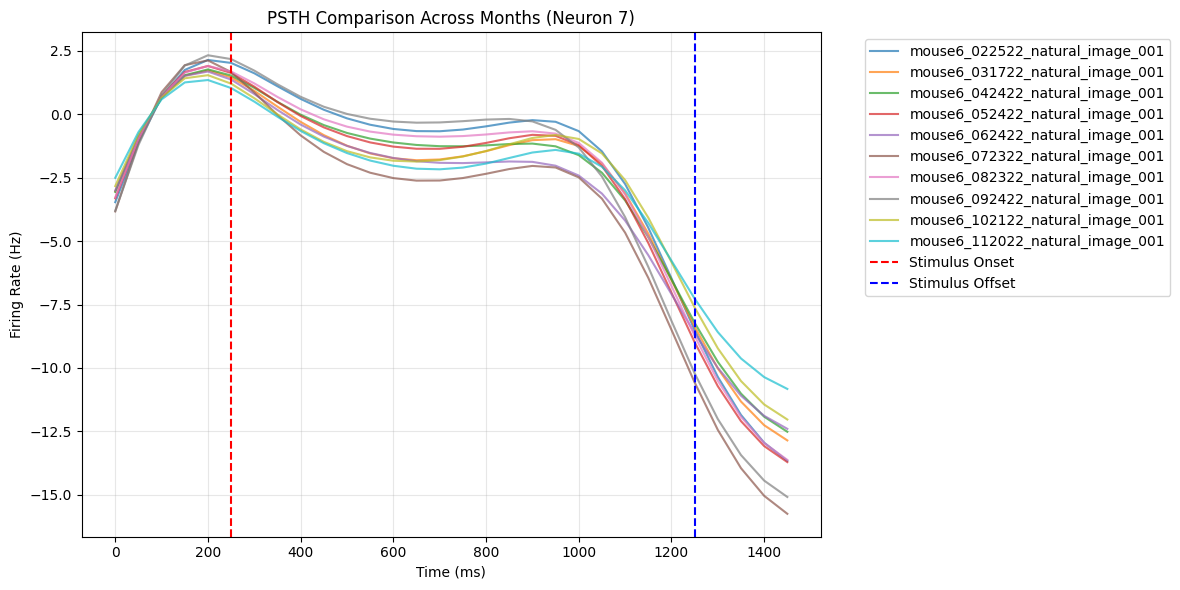

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for sname in train_sessions:
    psth_mean = psth_dict[sname].mean(axis=0)[:, 15]  # neuron 7的平均PSTH
    time_bins = np.arange(len(psth_mean)) * bin_size_ms  # 转换为毫秒
    plt.plot(time_bins, psth_mean, label=sname, alpha=0.7)

plt.axvline(x=EXTEND_TIME * 1000, color='red', linestyle='--', label='Stimulus Onset')
plt.axvline(x=(EXTEND_TIME + STIMULUS_DURATION) * 1000, color='blue', linestyle='--', label='Stimulus Offset')
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')
plt.title('PSTH Comparison Across Months (Neuron 7)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
